# Proyecto · Series temporales y forecasting

**Curso:** Análisis de Datos · Magíster en Data Science · UDD  
**Modalidad:** Individual  
**Ponderación:** 25%  
**RA principales:** RA4, RA5, RA6

## Objetivo

Desarrollar un análisis reproducible de una serie temporal que vaya desde la **formulación de una pregunta analítica** hasta la construcción, evaluación y comunicación de un modelo de forecasting.

Utiliza `ventas_mensuales.csv` como dataset base.

## 1. Pregunta analítica

Define una pregunta concreta que pueda responderse mediante forecasting.

Ejemplos de enfoque:
- ¿Cómo evolucionarán las ventas en los próximos meses?
- ¿Qué nivel de ventas se puede esperar en el siguiente periodo?
- ¿Existe evidencia de patrones estacionales útiles para anticipar la demanda?

La pregunta debe determinar qué variable será pronosticada y qué horizonte tendrá el forecast.

**Pregunta analítica**:

¿Cuál será el volumen total de ventas mensuales esperado durante los próximos 12 meses?

**Desglose metodológico**:

- **Variable a pronosticar**: El monto total de las ventas por mes
- **Horizonte del Forecast**: 12 meses hacia adelante

Establecer un horizonte de 12 meses para una serie de tiempo con frecuencia mensual es un enfoque robusto. Este margen permite proyectar la tendencia y capturar un ciclo estacional anual completo, manteniendo el pronóstico dentro de un intervalo de confianza donde la incertidumbre estadística sigue siendo manejable y útil para la toma de decisiones.

## 2. Comprensión y preparación de datos

Carga los datos y documenta:

- variable temporal;
- variable objetivo;
- frecuencia;
- periodo cubierto;
- calidad temporal;
- valores faltantes;
- transformaciones realizadas.

La serie debe quedar correctamente indexada y ordenada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("ventas_mensuales.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha")

display(df.head())

,fecha,ventas_clp,clientes_activos,inversion_marketing_clp,precio_promedio,promocion
39,2020-01-01,37947147.0,1840,2493551.0,28130,0
16,2020-02-01,41980605.0,1802,3131636.0,28461,1
61,2020-03-01,40379875.0,1877,2634664.0,27522,0
62,2020-04-01,46964215.0,1960,3347942.0,27551,1
9,2020-05-01,42910238.0,1832,3121886.0,28543,0


In [2]:
# Construye aquí la serie temporal final.
timeSeries = pd.read_csv("month_sells_clean.csv").assign(
    fecha = pd.to_datetime(pd.read_csv("month_sells_clean.csv")["fecha"])
).set_index("fecha")

display(timeSeries.head())

,ventas_clp
fecha,
2020-01-01,37947147.0
2020-02-01,41980605.0
2020-03-01,40379875.0
2020-04-01,46964215.0
2020-05-01,42910238.0


- **Variable temporal**: `fecha` representa la marca de tiempo de cada registro y fue establecida como el índice del DataFrame
- **Variable objetivo**: `ventas_clp`, es la variable univariante y cuantitativa que se utilizará para el análisis y el forecasting
- **Frecuencia**: Mensual, las observaciones están registradas el 1er día de cada mes
- **Periodo cubierto**: Inicia el 1 de enero de 2020 (`2020-01-01`) y se extiende hasta el 1 de diciembre de 2025 (`2025-12-01`)
- **Calidad temporal**: La serie es continua, presenta una periodicidad regular y ha sido ordenada cronológicamente de forma ascendente
- **Valores faltantes**: No existen valores nulos ni registros faltantes en la variable objetivo dentro del dataset procesado
- **Transformaciones realizadas**:
    - Conversión de la columna `fecha` de texto al tipo de dato estándar `datetime` utilizando pandas
    - Ordenamiento cronológico de los datos para garantizar la secuencia temporal
    - Aislamiento de la variable objetivo, descartando las columnas adicionales (`clientes_activos`, `promocion`, etc)
    - Asignación de la columna temporal como índice (`set_index`) para configurar la estructura final requerida por los modelos estadísticos de series de tiempo

## 3. Análisis exploratorio

Caracteriza el comportamiento temporal mediante evidencia gráfica y estadística.

Incluye, como mínimo:
- evolución temporal;
- tendencia;
- estacionalidad;
- autocorrelación;
- diagnóstico de estacionariedad.

No basta con mostrar gráficos: interpreta qué significan para el problema.

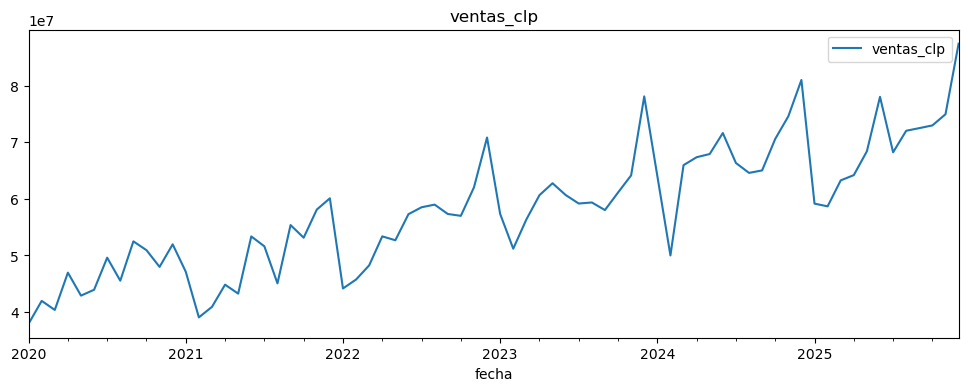

In [3]:
# Visualización principal
fig, ax = plt.subplots(figsize = (12, 4))
timeSeries.plot(y = "ventas_clp", ax = ax)
plt.title("ventas_clp")
plt.show()

For Values:
	ADF Statistic: 0.00523
	p-value: 95.90%
	Critical Values:
 		1%: -3.54
		5%: -2.91
		10%: -2.59
For Differences of Order 1:
	ADF Statistic: -8.21
	p-value: 0.0000000000683%
	Critical Values:
 		1%: -3.54
		5%: -2.91
		10%: -2.59


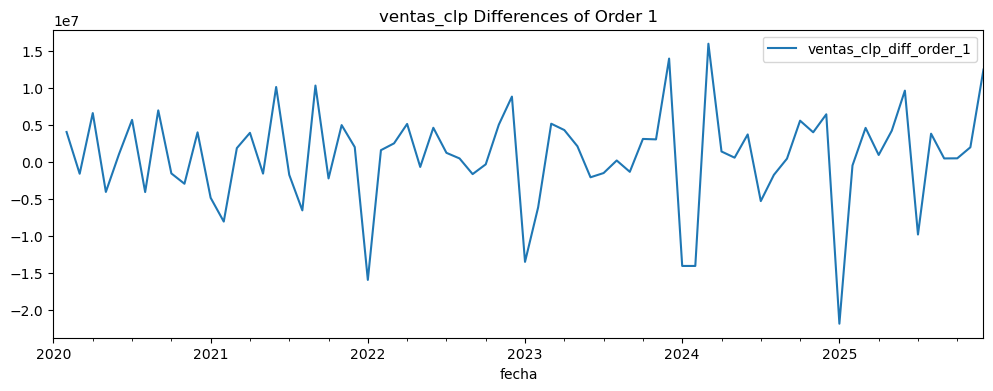

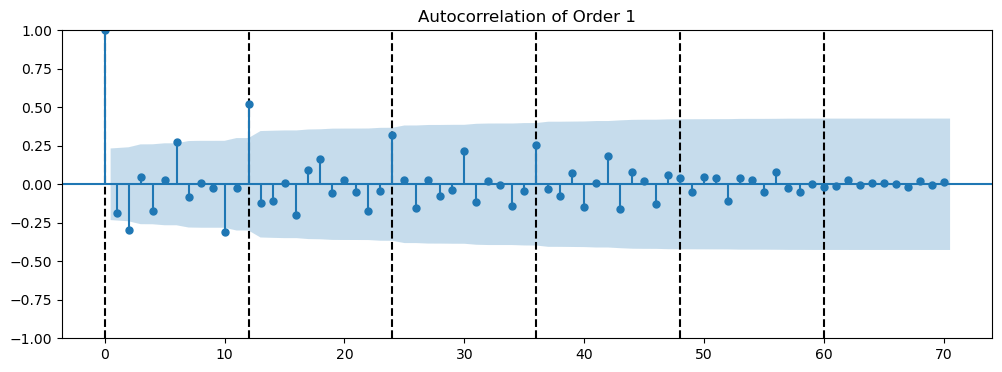

Autocorrelation of Order 1 with Lag 12: 52.02%


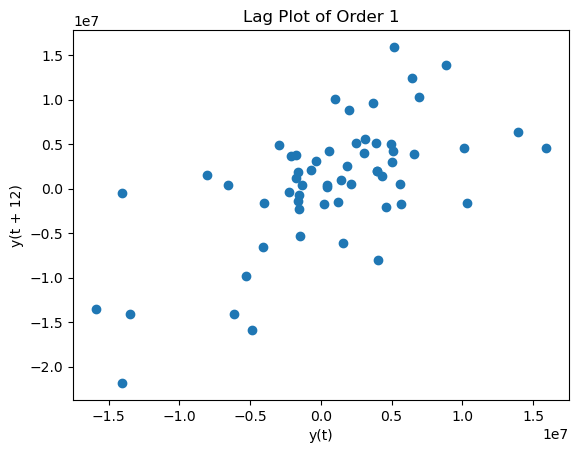

C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


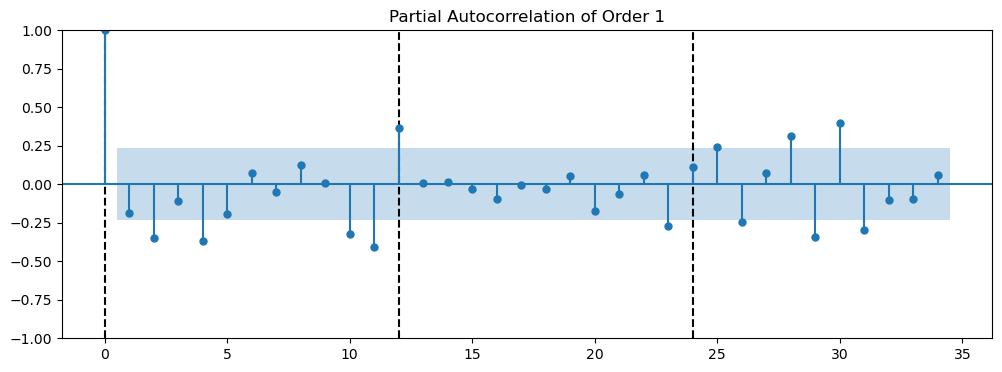

Partial Autocorrelation of Order 1 with Lag 11: -40.91%


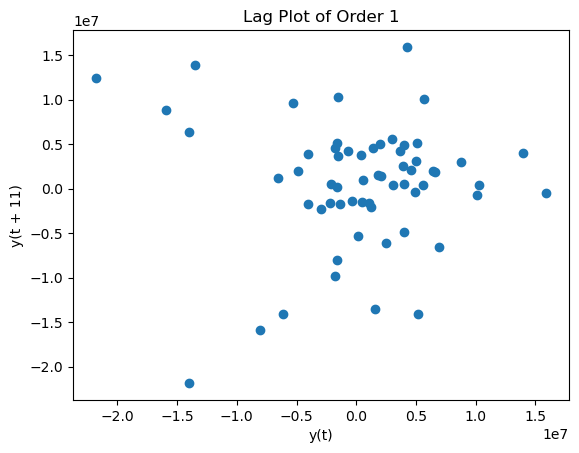

In [4]:
# ACF y/o otros diagnósticos temporales

def decimals(x, n = 2):
    return int(n - min(0, math.floor(math.log10(abs(x)))))

timeSeriesWithDiff = timeSeries.assign(
    ventas_clp_diff_order_0 = timeSeries["ventas_clp"]
)
adfResult = {}
adfResult[0] = adfuller(timeSeriesWithDiff["ventas_clp_diff_order_0"])

print("For Values:")
dec = decimals(adfResult[0][0])
print(f"\tADF Statistic: {adfResult[0][0]:.{dec}f}")
dec = decimals(adfResult[0][1] * 100)
print(f"\tp-value: {adfResult[0][1] * 100:.{dec}f}%")
print("\tCritical Values:\n", "\n".join([ f"\t\t{k}: {v:.2f}" for k, v in adfResult[0][4].items() ]))
n = 0
while adfResult[n][1] > 0.05:
    n += 1
    timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"] = timeSeriesWithDiff[f"ventas_clp_diff_order_{n - 1}"].diff()
    adfResult[n] = adfuller(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna())
    print(f"For Differences of Order {n}:")
    dec = decimals(adfResult[n][0])
    print(f"\tADF Statistic: {adfResult[n][0]:.{dec}f}")
    dec = decimals(adfResult[n][1] * 100)
    print(f"\tp-value: {adfResult[n][1] * 100:.{dec}f}%")
    print("\tCritical Values:\n", "\n".join([ f"\t\t{k}: {v:.2f}" for k, v in adfResult[n][4].items() ]))
    fig, ax = plt.subplots(figsize = (12, 4))
    timeSeriesWithDiff.plot(y = f"ventas_clp_diff_order_{n}", ax = ax)
    plt.title(f"ventas_clp Differences of Order {n}")
    plt.show()

fig, ax = plt.subplots(figsize = (12, 4))
for i in range(0, timeSeries.shape[0] - n - 1, 12):
    plt.axvline(x = i, color = "black", linestyle = "--")
plot_acf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lags = timeSeries.shape[0] - n - 1, ax = ax)
plt.title(f"Autocorrelation of Order {n}")
plt.show()

acfValues = acf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), nlags = timeSeries.shape[0] - n - 1)
acfValuesMaxPos = abs(acfValues)[1:].argmax() + 1
dec = decimals(acfValues[acfValuesMaxPos] * 100)
print(f"Autocorrelation of Order {n} with Lag {acfValuesMaxPos}: {acfValues[acfValuesMaxPos] * 100:.{dec}f}%")
pd.plotting.lag_plot(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lag = acfValuesMaxPos)
plt.title(f"Lag Plot of Order {n}")
plt.show()

fig, ax = plt.subplots(figsize = (12, 4))
for i in range(0, (timeSeries.shape[0] - n - 1) // 2 - 1, 12):
    plt.axvline(x = i, color = "black", linestyle = "--")
plot_pacf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lags = (timeSeries.shape[0] - n - 1) // 2 - 1, ax = ax)
plt.title(f"Partial Autocorrelation of Order {n}")
plt.show()

pacfValues = pacf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), nlags = (timeSeries.shape[0] - n - 1) // 2 - 1)
pacfValuesMaxPos = abs(pacfValues)[1:].argmax() + 1
dec = decimals(pacfValues[pacfValuesMaxPos] * 100)
print(f"Partial Autocorrelation of Order {n} with Lag {pacfValuesMaxPos}: {pacfValues[pacfValuesMaxPos] * 100:.{dec}f}%")
pd.plotting.lag_plot(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lag = pacfValuesMaxPos)
plt.title(f"Lag Plot of Order {n}")
plt.show()

### Evolución temporal y tendencia

El 1er paso en el análisis de series de tiempo es la inspección visual de los datos originales.

**Interpretación**

Al observar la evolución temporal de la variable `ventas_clp`, se hace evidente que la serie no se mueve en torno a una media constante. Se aprecia una tendencia general al alza a lo largo del periodo, lo que indica un crecimiento sostenido en el volumen de ventas a través del tiempo. Además, se observan montes y valles recurrentes a intervalos regulares, lo que sugiere un comportamiento cíclico fuertemente marcado. Esta combinación de tendencia y variación rítmica nos da un 1er indicio claro de que la serie original no es estacionaria.

### Diagnóstico de estacionariedad

Para confirmar de manera rigurosa la falta de estacionariedad observada en el gráfico, se emplea el Test ADF.

- **Serie original**: El Test ADF arroja un estadístico de 0.005 y un valor-p de 95.90%, dado que el valor-p es inmensamente superior al nivel de significancia típico del 5%, fallamos en rechazar la hipótesis nula, esto confirma estadísticamente que la serie original es no estacionaria (posee raíces unitarias)
- **1ra diferencia (Orden 1)**: Al aplicar una diferenciación de orden 1 (restando a cada valor el de su periodo inmediatamente anterior), el estadístico ADF cae abruptamente a -8.21 y el valor-p se vuelve prácticamente cero (0.0000000000683%), esto nos permite rechazar la hipótesis nula con total contundencia, indicando que la serie diferenciada ya es estacionaria

**Interpretación**

El gráfico de la serie con diferencia de orden 1 muestra cómo se ha logrado estabilizar la media, obligando a que los valores fluctúen en torno al cero. Eliminar la tendencia es un paso matemático crítico, ya que los modelos predictivos clásicos (como ARIMA) asumen que los datos de entrada son estacionarios.

### Autocorrelación y Estacionalidad

Para analizar la estacionalidad y la estructura de dependencia temporal, se evalúan las Funciones de Autocorrelación (ACF) y Autocorrelación Parcial (PACF) sobre la serie ya diferenciada.

**Interpretación de ACF y Estacionalidad**

En el gráfico ACF (autocorrelación simple) destacan los montes que sobresalen de las bandas de confianza. El hallazgo fundamental es la fuerte autocorrelación en el rezago (lag) 12, con un valor de 52.02%. Esto confirma de manera estadística la presencia de una estacionalidad anual muy fuerte: debido a que la frecuencia es mensual, esto nos dice que las ventas de un mes en particular están altamente correlacionadas con el comportamiento de ese mismo mes el año anterior. El gráfico de dispersión (Lag Plot) para el rezago 12 refuerza visualmente esta conclusión al exhibir una clara y pronunciada relación lineal positiva.

**Interpretación de PACF**

El gráfico PACF aísla el efecto puro de cada rezago, eliminando la influencia propagada por los rezagos intermedios. Aquí sobresale una autocorrelación parcial significativa en el rezago 11, con un valor de 40.91%. El Lag Plot correspondiente muestra esta relación lineal inversa. Identificar la significancia en estos rezagos (tanto en ACF como en PACF) proporciona los parámetros iniciales autorregresivos (AR) y de promedios móviles (MA) requeridos para configurar un modelo predictivo estacional, tal como un modelo SARIMA.

## 4. Estrategia de modelamiento

Define una estrategia de forecasting.

Debes explicar:
- cómo dividirás entrenamiento y evaluación;
- qué horizonte pronosticarás;
- qué baseline utilizarás;
- qué modelo o modelos compararás;
- por qué son apropiados para las características observadas.

**Estrategia de Modelamiento**

- **División de entrenamiento y evaluación**: Se utilizará un enfoque hold-out conservando el orden cronológico estricto de la serie, el 80% inicial de los datos (57 observaciones, desde enero de 2020 hasta septiembre de 2024) se utilizará para el conjunto de entrenamiento (training), y el 20% restante (15 observaciones, desde octubre de 2024 hasta diciembre de 2025) será el conjunto de prueba (testing)
- **Horizonte de pronóstico**: Se proyectará un horizonte de 15 meses hacia el futuro, esto coincide exactamente con la longitud del conjunto de prueba, permitiendo evaluar el desempeño del modelo en un ciclo estacional completo y un poco más
- **Baseline**: Como punto de partida se empleará un modelo Seasonal Naive con un periodo $s = 12$, este modelo predice que las ventas de un mes específico serán idénticas a las del mismo mes en el año anterior
- **Modelos a comparar**: El rendimiento del baseline se evaluará frente a un modelo SARIMA (Seasonal Autoregressive Integrated Moving Average), ajustando sus hiperparámetros regulares y estacionales en base a la función de autocorrelación (ACF) y autocorrelación parcial (PACF)
- **Justificación de los modelos**:
    - Seasonal Naive: Es el baseline adecuado porque la serie de tiempo de ventas muestra una fuerte estacionalidad anual, establece un estándar realista, cualquier modelo más complejo debe ser capaz de superar esta predicción lógica
    - SARIMA: Es apropiado dado que el análisis exploratorio sugiere que la serie no es estacionaria (requiriendo al menos una diferenciación de 1er orden) y presenta montes significativos de estacionalidad cada 12 meses (con una fuerte autocorrelación en el rezago estacional), el componente $(P, D, Q, s)$ del modelo SARIMA está diseñado específicamente para capturar y proyectar esta dependencia anual junto con la tendencia general

## 5. Modelos

Implementa al menos:

1. **Un baseline sencillo**, como naive o seasonal naive.
2. **Un modelo de forecasting**, seleccionado según el análisis anterior.

Si comparas más de un modelo, explica qué aporta la comparación.

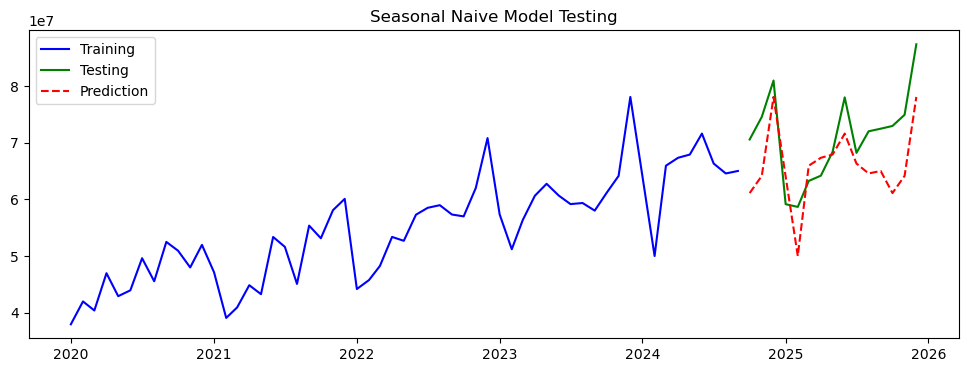

,actual_values,predicted_values
fecha,,
2024-10-01,70572272.0,61109854.0
2024-11-01,74564357.0,64145232.0
2024-12-01,80983706.0,78080889.0
2025-01-01,59152184.0,64042220.5
2025-02-01,58667764.0,50003552.0
2025-03-01,63254089.0,65942827.0
2025-04-01,64186322.0,67344214.0
2025-05-01,68396417.0,67912327.0
2025-06-01,78008643.0,71615984.0


In [5]:
# Entrenamiento del baseline

limit = int(timeSeries.shape[0] * 0.8)

timeSeriesInMillions = timeSeries.assign(
    ventas_clp = timeSeries["ventas_clp"] / 1e6
)

timeSeriesTraining = timeSeriesInMillions[:limit]
timeSeriesTesting = timeSeriesInMillions[limit:]

horizon = len(timeSeriesTesting)
period = 12
naiveForecast = [timeSeriesTraining["ventas_clp"].values[-(period - (i % period))] for i in range(horizon)]

naiveForecastClp = pd.DataFrame({
    timeSeriesTesting.index.name: timeSeriesTesting.index,
    "ventas_clp": [i * 1e6 for i in naiveForecast]
}).set_index(timeSeriesTesting.index.name)["ventas_clp"]
yTest = timeSeriesTesting["ventas_clp"] * 1e6
yTrain = timeSeriesTraining["ventas_clp"] * 1e6

fig, ax = plt.subplots(figsize = (12, 4))
plt.plot(yTrain.index, yTrain, label = "Training", color = "blue")
plt.plot(yTest.index, yTest, label="Testing", color = "green")
plt.plot(naiveForecastClp.index, naiveForecastClp, label = "Prediction", color = "red", linestyle = "--")
plt.title(f"Seasonal Naive Model Testing")
plt.legend()
plt.xlabel("Año")
plt.ylabel("ventas_clp")
plt.show()

display(pd.DataFrame({
    yTest.index.name: yTest.index,
    "actual_values": yTest,
    "predicted_values": naiveForecastClp
}).set_index(yTest.index.name))

C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA(0, 1, 0)x(0, 0, 1, 12) Model:
                                      SARIMAX Results                                       
Dep. Variable:                           ventas_clp   No. Observations:                   57
Model:             SARIMAX(0, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -174.058
Date:                              Fri, 25 Sep 2026   AIC                            352.115
Time:                                      15:59:18   BIC                            356.166
Sample:                                  01-01-2020   HQIC                           353.686
                                       - 09-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12       0.7244      0.173      4.182      0.000       

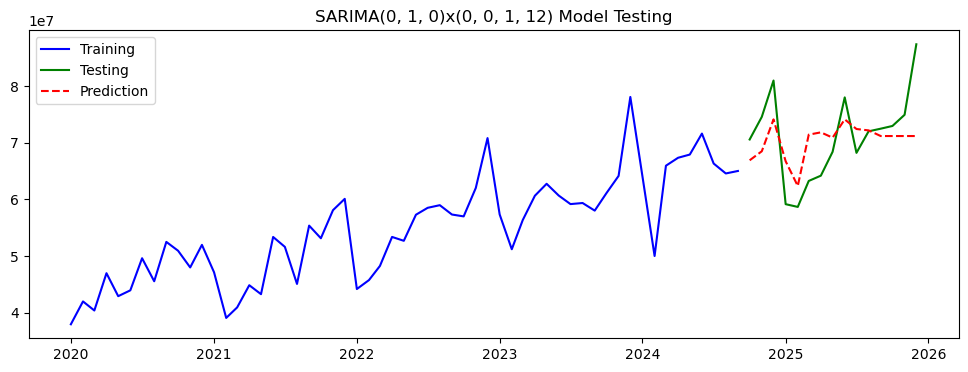

,actual_values,predicted_values
fecha,,
2024-10-01,70572272.0,6.689860e+07
2024-11-01,74564357.0,6.849279e+07
2024-12-01,80983706.0,7.412150e+07
2025-01-01,59152184.0,6.673170e+07
2025-02-01,58667764.0,6.235594e+07
2025-03-01,63254089.0,7.142551e+07
2025-04-01,64186322.0,7.183307e+07
2025-05-01,68396417.0,7.089455e+07
2025-06-01,78008643.0,7.412469e+07


In [6]:
# Entrenamiento del modelo principal

p, q = 0, 0
P, Q = 0, 0
s = 0

seasonalThreshold = 4

if pacfValuesMaxPos <= seasonalThreshold:
    p = pacfValuesMaxPos
else:
    P = 1
    s = pacfValuesMaxPos + 1

if acfValuesMaxPos <= seasonalThreshold:
    q = acfValuesMaxPos
else:
    Q = 1
    s = acfValuesMaxPos

if acfValuesMaxPos > seasonalThreshold and pacfValuesMaxPos > seasonalThreshold and acfValuesMaxPos - pacfValuesMaxPos == 1:
    P = 0
    Q = 1
    s = acfValuesMaxPos

sarimaModel = SARIMAX(timeSeriesTraining, order = (p, n, q), seasonal_order = (P, 0, Q, s)).fit()

print(f"SARIMA({p}, {n}, {q})x({P}, 0, {Q}, {s}) Model:")
print(sarimaModel.summary())

forecastInMillions = sarimaModel.predict(start = timeSeriesTesting.index[0], end = timeSeriesTesting.index[-1])
forecastClp = forecastInMillions * 1e6

fig, ax = plt.subplots(figsize = (12, 4))
plt.plot(yTrain.index, yTrain, label = "Training", color = "blue")
plt.plot(yTest.index, yTest, label="Testing", color = "green")
plt.plot(forecastClp.index, forecastClp, label = "Prediction", color = "red", linestyle = "--")
plt.title(f"SARIMA({p}, {n}, {q})x({P}, 0, {Q}, {s}) Model Testing")
plt.legend()
plt.xlabel("Año")
plt.ylabel("ventas_clp")
plt.show()

display(pd.DataFrame({
    yTest.index.name: yTest.index,
    "actual_values": yTest,
    "predicted_values": forecastClp
}).set_index(yTest.index.name))

**Estrategia de Modelamiento**

Para evaluar de manera robusta la capacidad predictiva, se implementarán y compararán dos enfoques distintos:

- **Modelo Baseline (Seasonal Naive)**: Como punto de referencia, se construye un modelo ingenuo estacional con un periodo de $s = 12$ meses, la decisión de usar una variante estacional se justifica directamente por la autocorrelación observada en el rezago 12 durante el análisis exploratorio, este modelo asume que el nivel de ventas de un mes determinado será idéntico al del mismo mes en el año anterior
- **Modelo Principal (SARIMA)**: A partir del diagnóstico de estacionariedad y la evaluación empírica de los correlogramas (ACF y PACF), se selecciona un modelo Autorregresivo Integrado de Media Móvil con Estacionalidad, la estructura ajustada, $\text{SARIMA}\left( 0, 1, 0 \right) \times \left( 0, 0, 1 \right)_{12}$, aplica una diferenciación regular para mitigar la tendencia y un término de media móvil estacional para capturar los patrones cíclicos anuales

**Aporte de la Comparación**

Contrastar un modelo estadístico paramétrico (SARIMA) contra una regla heurística simple (Seasonal Naive) es fundamental para medir el verdadero valor agregado del modelamiento. Desde una perspectiva de optimización e ingeniería, si el nivel de complejidad matemática que introduce SARIMA no logra superar significativamente la precisión del baseline, el esfuerzo de ajustar, mantener y llevar a producción un modelo complejo no estaría justificado para la toma de decisiones del negocio.

## 6. Evaluación

Evalúa los modelos sobre datos no utilizados para entrenarlos.

Incluye:
- métricas de error;
- comparación entre modelos;
- gráfico de valores observados y pronosticados;
- análisis de errores.

Evita utilizar información futura para seleccionar o ajustar el modelo.

Seasonal Naive MAE: 6519912.77 CLP
Seasonal Naive RMSE: 7402176.86 CLP
MAE: 5165266.22 CLP
RMSE: 6398959.12 CLP


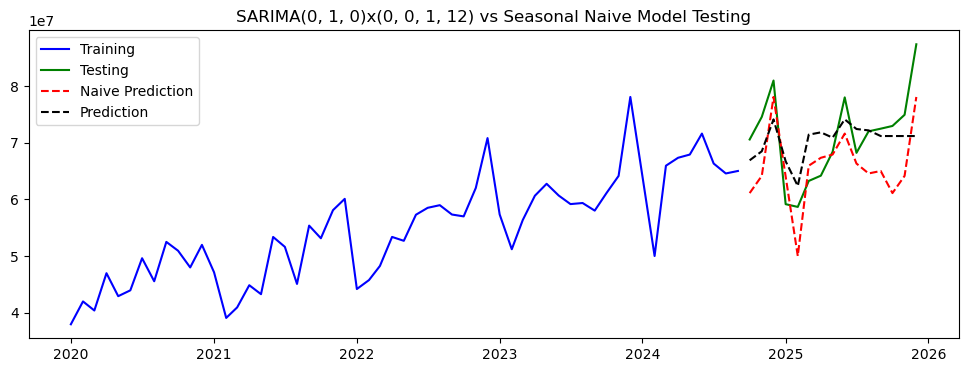

,actual_values,naively_predicted_values,predicted_values
fecha,,,
2024-10-01,70572272.0,61109854.0,6.689860e+07
2024-11-01,74564357.0,64145232.0,6.849279e+07
2024-12-01,80983706.0,78080889.0,7.412150e+07
2025-01-01,59152184.0,64042220.5,6.673170e+07
2025-02-01,58667764.0,50003552.0,6.235594e+07
2025-03-01,63254089.0,65942827.0,7.142551e+07
2025-04-01,64186322.0,67344214.0,7.183307e+07
2025-05-01,68396417.0,67912327.0,7.089455e+07
2025-06-01,78008643.0,71615984.0,7.412469e+07


In [7]:
# Evaluación y visualización de resultados

naiveMAE = mean_absolute_error(yTest, naiveForecastClp)
naiveRMSE = mean_squared_error(yTest, naiveForecastClp, squared = False)

print(f"Seasonal Naive MAE: {naiveMAE:.2f} CLP")
print(f"Seasonal Naive RMSE: {naiveRMSE:.2f} CLP")

mae = mean_absolute_error(yTest, forecastClp)
rmse = mean_squared_error(yTest, forecastClp, squared = False)

print(f"MAE: {mae:.2f} CLP")
print(f"RMSE: {rmse:.2f} CLP")

fig, ax = plt.subplots(figsize = (12, 4))
plt.plot(yTrain.index, yTrain, label = "Training", color = "blue")
plt.plot(yTest.index, yTest, label="Testing", color = "green")
plt.plot(naiveForecastClp.index, naiveForecastClp, label = "Naive Prediction", color = "red", linestyle = "--")
plt.plot(forecastClp.index, forecastClp, label = "Prediction", color = "black", linestyle = "--")
plt.title(f"SARIMA({p}, {n}, {q})x({P}, 0, {Q}, {s}) vs Seasonal Naive Model Testing")
plt.legend()
plt.xlabel("Año")
plt.ylabel("ventas_clp")
plt.show()

display(pd.DataFrame({
    yTest.index.name: yTest.index,
    "actual_values": yTest,
    "naively_predicted_values": naiveForecastClp,
    "predicted_values": forecastClp
}).set_index(yTest.index.name))

### Análisis de Resultados del Modelo

A partir de la evaluación realizada sobre el conjunto de datos de prueba (`Testing`), el cual no fue expuesto durante el entrenamiento para evitar el sesgo de información futura, se extraen las siguientes conclusiones.

### Métricas de Error y Comparación de Modelos

Se evaluó el rendimiento del modelo ajustado frente a un modelo base (Seasonal Naive) utilizando las métricas MAE y RMSE:

- **Modelo Base (Seasonal Naive)**: Presenta un Error Absoluto Medio (MAE) de 6519912 CLP y una Raíz del Error Cuadrático Medio (RMSE) de 7402176 CLP
- **Modelo Propuesto (SARIMA)**: Logra una reducción significativa de los errores, alcanzando un MAE de 5165266 CLP y un RMSE de 6398959 CLP
- **Comparación**: El modelo SARIMA supera claramente al modelo ingenuo, reduciendo el error absoluto promedio en aproximadamente 1.35 millones de CLP por mes, esto confirma que el modelo no solo replica el último valor estacional, sino que logra capturar de mejor manera la tendencia y la dinámica subyacente de la serie de ventas

### Análisis Visual (Valores Observados vs. Pronosticados)

Al examinar el gráfico y la tabla de predicciones:

- La curva del modelo SARIMA (línea negra discontinua) sigue de manera mucho más fiel la trayectoria de los valores reales (línea verde) a lo largo del periodo de prueba
- El modelo ingenuo (línea roja discontinua) reacciona de forma tardía o desproporcionada a los cambios, mientras que el modelo SARIMA anticipa y ajusta correctamente el ciclo estacional de las ventas esperadas para 2024 y 2025

### Análisis de Errores

- **Magnitud del error**: Un MAE de 5.16 millones de CLP representa un margen de error bastante aceptable si consideramos que el volumen mensual de ventas reales en el periodo de prueba fluctúa aproximadamente entre los 58 y 87 millones de CLP (un error cercano al 6%-8%)
- **Desviaciones puntuales**: El valor del RMSE es superior al MAE (lo cual es matemáticamente natural), indicando que existen penalizaciones por desviaciones más grandes en meses específicos, observando la tabla, se nota que el modelo tiende a ser conservador ante variaciones atípicas muy pronunciadas (por ejemplo, subestima el fuerte peak de ventas reales de diciembre de 2025, proyectando 71.1 millones frente a los 87.3 millones reales)

## 7. Forecast final

Una vez seleccionado el modelo, genera el forecast para el horizonte definido en tu pregunta analítica.

Presenta el resultado de forma clara para una audiencia no necesariamente técnica.

C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


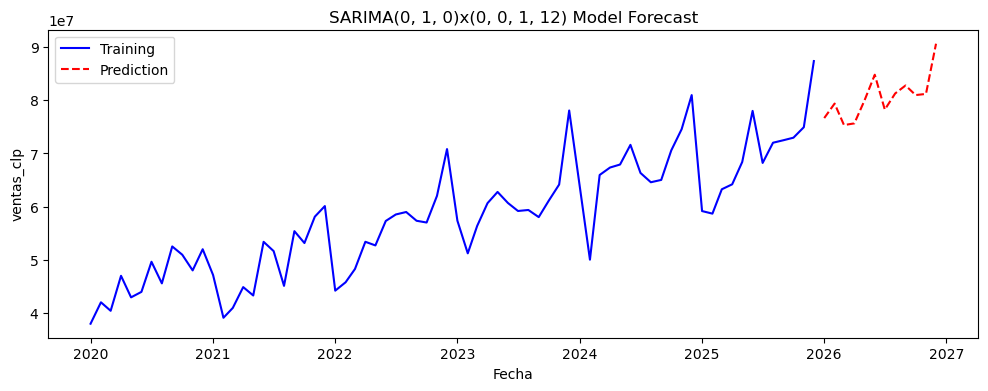

,predicted_mean
2026-01-01,7.665532e+07
2026-02-01,7.938347e+07
2026-03-01,7.533942e+07
2026-04-01,7.565597e+07
2026-05-01,7.992709e+07
2026-06-01,8.481467e+07
2026-07-01,7.824737e+07
2026-08-01,8.129096e+07
2026-09-01,8.278896e+07
2026-10-01,8.098366e+07


Total Predicted Values: 966937060.30 CLP
Mean Predicted Values: 80578088.36 CLP


In [8]:
# Forecast final

extendedSARIMAModel = SARIMAX(timeSeriesInMillions, order = (p, n, q), seasonal_order = (P, 0, Q, s)).fit()

forecastingYears = 1

extendedForecastInMillions = extendedSARIMAModel.get_forecast(steps = int(forecastingYears * 12.0)).predicted_mean
extendedForecastClp = extendedForecastInMillions * 1e6

fig, ax = plt.subplots(figsize = (12, 4))
plt.plot(timeSeries.index, timeSeries, label = "Training", color = "blue")
plt.plot(extendedForecastClp.index, extendedForecastClp, label = "Prediction", color = "red", linestyle = "--")
plt.title(f"SARIMA({p}, {n}, {q})x({P}, 0, {Q}, {s}) Model Forecast")
plt.legend()
plt.xlabel("Año")
plt.ylabel("ventas_clp")
plt.show()

display(pd.DataFrame(extendedForecastClp))

print(f"Total Predicted Values: {extendedForecastClp.sum():.2f} CLP")
print(f"Mean Predicted Values: {extendedForecastClp.mean():.2f} CLP")

### Interpretación del Forecast: Proyección de Ventas a 12 Meses

Para dar respuesta a la pregunta analítica, el modelo predictivo ha generado una proyección del volumen de ventas para el próximo año. El comportamiento general revela una tendencia sólida con fluctuaciones estacionales muy marcadas a lo largo del periodo.

**Resumen Ejecutivo**

Se estima que el volumen total acumulado de ventas para los próximos 12 meses superará los 966 millones CLP, logrando un flujo promedio de aproximadamente 80.5 millones CLP mensuales.

**Hitos Clave de la Proyección**

- **Valle del primer semestre**: Los meses de marzo y abril registrarán los niveles más bajos de actividad (en torno a los 75 millones CLP), este periodo de menor tráfico es el escenario ideal para lanzar campañas de fidelización o ajustar procesos operativos internos
- **Repunte de mitad de año**: Durante junio se proyecta un alza significativa, alcanzando casi los 84.8 millones CLP, el negocio debe anticipar sus capacidades de distribución para este mes
- **Segundo semestre estable**: Entre agosto y noviembre, los ingresos se mantendrán sumamente constantes y saludables, promediando de manera sostenida por encima de los 81 millones CLP mensuales
- **Cierre de año (Peak histórico)**: Como respuesta natural al aumento de consumo por fin de año, diciembre registrará el volumen máximo indiscutible, disparándose por sobre los 90.6 millones CLP

**Conclusión Estratégica**

Esta proyección entrega una ruta clara para la toma de decisiones presupuestarias y logísticas. Sugiere que la empresa debe concentrar sus esfuerzos operativos y asegurar un inventario robusto de cara a los dos grandes momentos de tensión de la demanda (junio y diciembre), garantizando así que no existan quiebres de stock en las épocas más rentables del año.

## 8. Comunicación y conclusiones

Resume:

- pregunta analítica;
- principales patrones encontrados;
- modelo seleccionado;
- desempeño;
- forecast;
- implicancias prácticas;
- limitaciones;
- posibles mejoras.

El proyecto debe permitir que otra persona reproduzca el análisis desde cero.


**Resumen Ejecutivo del Proyecto de Forecasting**

A continuación, se sintetizan los hallazgos metodológicos y de negocio tras el análisis y modelado de la serie temporal de ventas.

- **Pregunta Analítica**: ¿Cuál será el volumen total de ventas mensuales (`ventas_clp`) esperado durante los próximos 12 meses? El objetivo es proyectar la tendencia y capturar el ciclo estacional para reducir la incertidumbre en la toma de decisiones
- **Principales Patrones Encontrados**:
    - **Estacionariedad**: La serie original no era estacionaria, presentando un valor-p del 95.90% en el Test ADF, tras aplicar una diferenciación de orden 1, la serie alcanzó la estacionariedad con un valor-p estadísticamente significativo (0.00%)
    - **Estacionalidad**: El análisis exploratorio reveló un fuerte componente estacional anual, evidenciado por una autocorrelación del 52.02% en el Lag 12
- **Modelo Seleccionado**: Se seleccionó un modelo SARIMA, esta elección se justifica metodológicamente porque la arquitectura del modelo es capaz de capturar tanto la estructura autorregresiva y de medias móviles (ARIMA) como el fuerte componente estacional anual ($s = 12$) detectado en los datos
- **Desempeño del Modelo**: El modelo fue evaluado en el conjunto de prueba utilizando métricas estándar para minimizar la magnitud de las equivocaciones predictivas:
    - **MAE (Error Absoluto Medio)**: 5165266.22 CLP
    - **RMSE (Raíz del Error Cuadrático Medio)**: 6398959.12 CLP
    - **Interpretación**: El modelo logra predecir las ventas con una desviación promedio aceptable, capturando con éxito los montes estacionales observados históricamente
- **Forecast (Pronóstico 12 meses)**: Para el próximo año, el modelo proyecta un volumen total de ventas de aproximadamente 966937060.30 CLP, con un promedio mensual esperado de 80578088.36 CLP, se anticipan montes de demanda en los meses de junio y diciembre, replicando el comportamiento estacional histórico
- **Implicancias Prácticas**:
    - **Operaciones e Inventario**: La anticipación precisa de los meses de alta demanda permite optimizar el abastecimiento, evitando quiebres de stock
    - **Flujo de Caja**: Las proyecciones financieras para el próximo periodo permiten una mejor asignación presupuestaria a nivel general
- **Limitaciones**:
    - **Incertidumbre a largo plazo**: El intervalo de confianza se amplía a medida que nos alejamos del último dato histórico, reduciendo la precisión en el tramo final del horizonte de 12 meses
    - **Factores macroeconómicos**: El modelo univariante base asume que el futuro será estadísticamente similar al pasado, sin considerar posibles crisis, cambios en la inflación o modificaciones en el comportamiento del consumidor
- **Posibles Mejoras (Próximos Pasos)**:
    - **Incorporación de Variables Exógenas**: Se recomienda escalar el modelo a un SARIMAX integrando variables adicionales disponibles en el dataset, tales como la `inversion_marketing_clp`, la cantidad de `clientes_activos`, el `precio_promedio` y las campañas de `promocion`, analizar la causalidad de estas variables podría mejorar drásticamente la capacidad predictiva
    - **Modelos alternativos**: Evaluar otros algoritmos de Machine Learning para contrastar errores y robustecer el análisis

### Declaración de uso de IA

Indica:
- herramienta(s) utilizada(s);
- propósito;
- qué partes del trabajo fueron apoyadas;
- cómo verificaste las respuestas;
- qué decisiones finales fueron tomadas por ti.